# Analysis of 1332 keV spectrum
In this notbook I will analyze the gamma spectrum for a single detector to determine the best way moving forward in generating the response matrix of the detectors.

In [73]:
%matplotlib widget
from histogram import *
import ompy as om
import numpy as np
import uproot as up
import arviz as az

import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.ndimage import gaussian_filter1d
from tqdm.notebook import trange, tqdm

def fwhm_ocl(E):
    return np.sqrt(60.6499 + 0.458252*E + 0.000265552*E**2)
def sigma_ocl(E): return fwhm_ocl(E) / (2*np.sqrt(2*np.log(2)))

In [152]:
# Read file from root file:
rfile = up.open("energy_1332keV_unaccelerated.root")
oclEvents4 = rfile['DataTreeSim']['OCLLABR_Energy4'].array(library='np')
oclEvent45 = np.concatenate((rfile['DataTreeSim']['OCLLABR_Energy0'].array(library='np'),
                             rfile['DataTreeSim']['OCLLABR_Energy1'].array(library='np'),
                             rfile['DataTreeSim']['OCLLABR_Energy2'].array(library='np'),
                             rfile['DataTreeSim']['OCLLABR_Energy3'].array(library='np')))

821 310


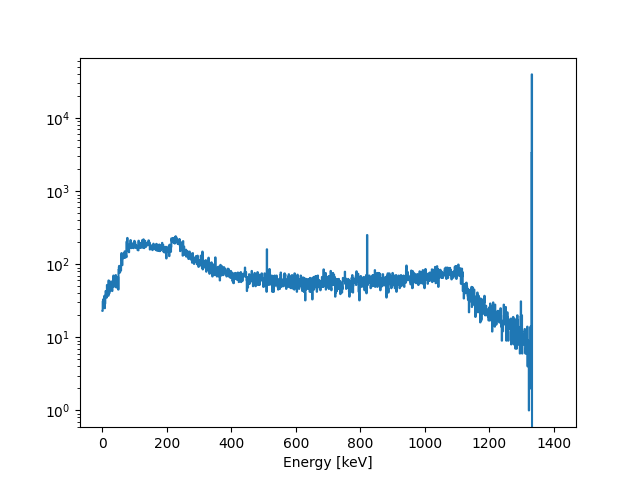

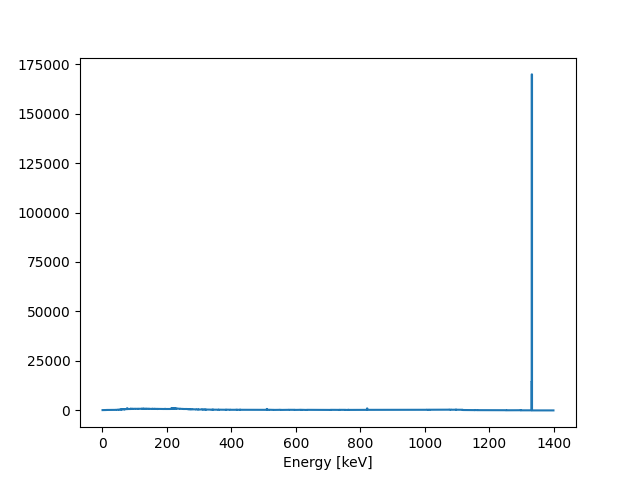

In [199]:
oclEvents4Hist = Histogram1D(oclEvents4[oclEvents4>0], bins=1400, range=(0, 1400))
oclEvents4Hist.plot(kind='step', scale='log')
oclEvents4Hist = Histogram1D(oclEvent45[oclEvent45>0], bins=1400, range=(0, 1400))
oclEvents4Hist.plot(kind='step')
print(1332 - 511, 1332 - 1022)

For each Eg bin we will draw 5000 from a Poission distribution with a mean equal to 65 photons / keV

  0%|          | 0/646542 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Energy [keV]'>)

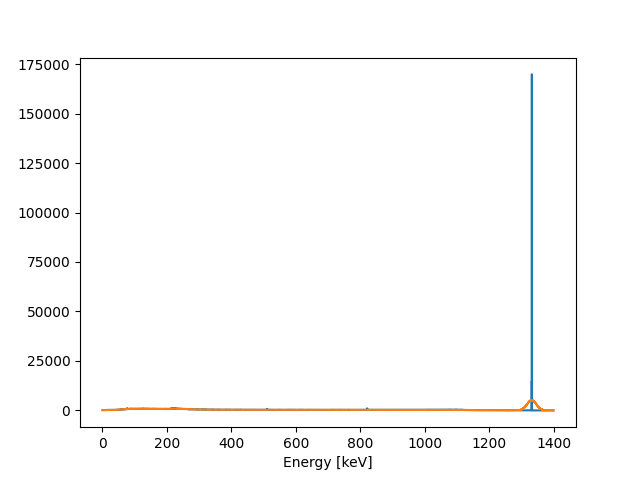

In [155]:
def make_histogram(events, bins, sigma_func):
    bin_values = np.zeros(len(bins)-1)
    bin_center = np.array([0.5*(bins[i+1]+bins[i]) for i in range(len(bins)-1)])
    sigma_bin = np.sqrt(2)*sigma_func(bin_center)
    for event in tqdm(events):
        w0 = erf((event - bins[1:])/sigma_bin)
        w1 = erf((event - bins[:-1])/sigma_bin)
        bin_values += 0.5*(w1 - w0)
    return om.Vector(values=bin_values, E=bin_center)
fig, ax = oclEvents4Hist.plot(kind='step')
make_histogram(oclEvent45[oclEvent45>0], np.arange(0, 1401, 1), sigma_func=sigma_ocl).plot(ax=ax, kind='step')

  0%|          | 0/646542 [00:00<?, ?it/s]

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Energy [keV]'>)

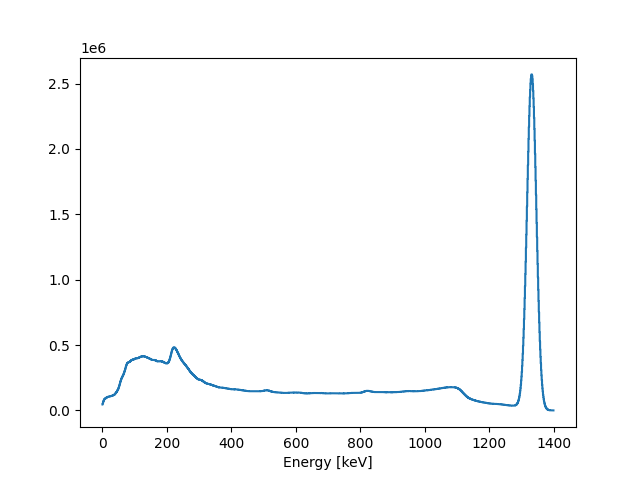

In [156]:
## How can we do this in a more reasonable way???
## For each event we can draw a random number from a gaussian with the resolution given by our function...
def fold(events, sigma):
    draws = []
    rng = np.random.default_rng()
    for event in tqdm(events):
        draws += list(rng.normal(event, scale=sigma(event), size=500))
    return Histogram1D(np.array(draws), bins=1400, range=(0, 1400))
fold(oclEvent45[oclEvent45>0], sigma=sigma_ocl).plot(kind='step')

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 1.398e+03, 1.399e+03,
       1.400e+03])

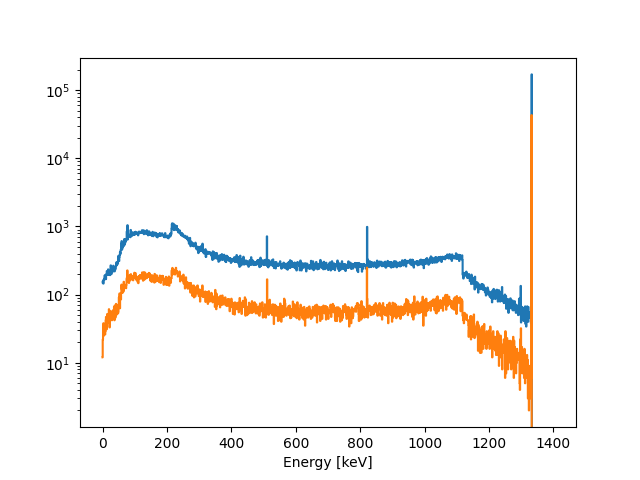

In [206]:
def HistogramData(events, bin_limits):
    bin_center = 0.5*(bin_limits[1:] + bin_limits[:-1])
    bin_counts = np.array([len(events[(bin_limits[i] <= events) & (events < bin_limits[i+1])]) for i in range(len(bin_center))])        
    return om.Vector(E=bin_center, values=bin_counts)
oclEvents4Hist2 = HistogramData(oclEvents4[oclEvents4>0], np.arange(-0.5, 1401, 1))
fig, ax = oclEvents4Hist.plot(kind='step')
oclEvents4Hist2.plot(kind='step', ax=ax, scale='log')
oclEvents4Hist2.E

59.06677468367391
259
101.5680946973776
(65, 3428, 3362)
59.55401197120442
178
42922
101.94976384601665
5.2e-06


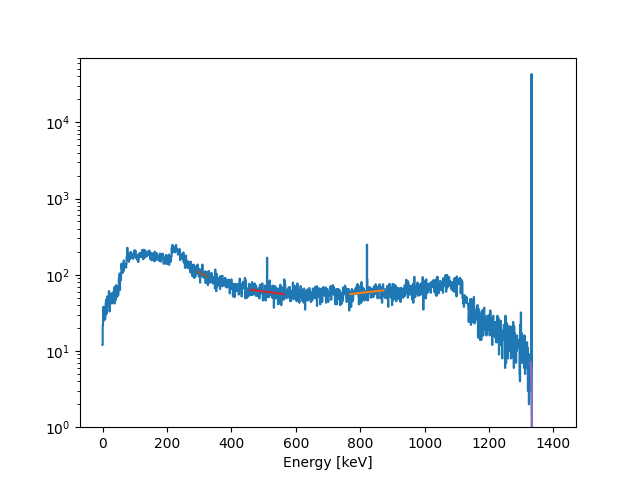

In [216]:
fig, ax = oclEvents4Hist2.plot(kind='step', scale='log')
ax.set_ylim(1)
def full_energy_counts(hist, inc_energy, holdoff=1):
    """ Extract the total number of counts in the full energy peak.
    We assume that the full energy peak can be in bins ± holdoff.
    """
    data = hist.cut(inc_energy-holdoff, inc_energy+holdoff, inplace=False)
    return np.sum(data.values)

def extract_peak_counts(hist, inc_energy, bg_width=50,holdoff=1, bg_type='lin', full=False, rebin=1):
    """ Extract the number of events within a peak.
        Args:
            hist: The actual histogram to extract from
            energy: The energy of the peak
            bg_width: The width in energy on both sides of the peak to extract the background, typically 20 keV
            holdoff: A 'safety' region of which we will avoid the peak before estimating the bg, typically 1 keV
    """

    lhs_bg = hist.cut(inc_energy-holdoff-bg_width, inc_energy-holdoff, inplace=False).rebin(factor=rebin, inplace=False)
    rhs_bg = hist.cut(inc_energy+holdoff, inc_energy+holdoff+bg_width, inplace=False).rebin(factor=rebin, inplace=False)

    frange = hist.cut(inc_energy-holdoff-bg_width, inc_energy+holdoff+bg_width, inplace=False)

    hrange = hist.cut(inc_energy-holdoff, inc_energy+holdoff, inplace=False)

    # Get the background polynomial
    counts = np.concatenate([lhs_bg.values, rhs_bg.values])
    energy = np.concatenate([lhs_bg.E, rhs_bg.E])

    if bg_type == 'lin':
        counts = np.concatenate([lhs_bg.values, rhs_bg.values]) / rebin
    if bg_type == 'exp':
        counts = np.log(np.concatenate([lhs_bg.values, rhs_bg.values]) / rebin)
    
    poly = np.polyfit(energy, counts, 1)
    e = np.linspace(energy[0], energy[-1], 1001)
    if bg_type == 'lin':
        ax.plot(e, np.polyval(poly, e))
    elif bg_type == 'exp':
        ax.plot(e, np.exp(np.polyval(poly, e)))
    bg_tot = 0

    bg_v2 = np.polyval(poly, hrange.E)
    #print(hrange.values - bg_v2)
    
    if bg_type == 'lin':
        bg_tot = np.sum(np.polyval(poly, frange.E))
    if bg_type == 'exp':
        bg_tot = np.sum(np.exp(np.polyval(poly, frange.E)))
        print(np.exp(np.polyval(poly, inc_energy)))
    
    if full:
        return int(np.sum(frange.values)-bg_tot), int(np.sum(frange.values)), int(bg_tot)
    else:
        return int(np.sum(frange.values)-bg_tot)
#print(full_energy_counts(oclEvents4Hist2, 1332.492, 1))
print(extract_peak_counts(oclEvents4Hist2, 1332.492-510.998, full=False, bg_type='exp'))
print(extract_peak_counts(oclEvents4Hist2, 1332.492-2*510.998, full=True, bg_width=15, rebin=2, bg_type='exp'))
print(extract_peak_counts(oclEvents4Hist2, 510.998, full=False, bg_type='exp'))
print(extract_peak_counts(oclEvents4Hist2, 1332.492, holdoff=1, bg_width=2, bg_type='lin'))

print(extract_peak_counts(oclEvents4Hist2, 1332.492-2*510.998, full=False, bg_width=15, bg_type='exp')/10e6)

In [217]:
print(59.55401197120442 / 10e6)
print(1.85e-05 / 4)
desc_eff = 1.85e-05 / 4
bsc_eff = 438 / 40e6

5.955401197120442e-06
4.625e-06


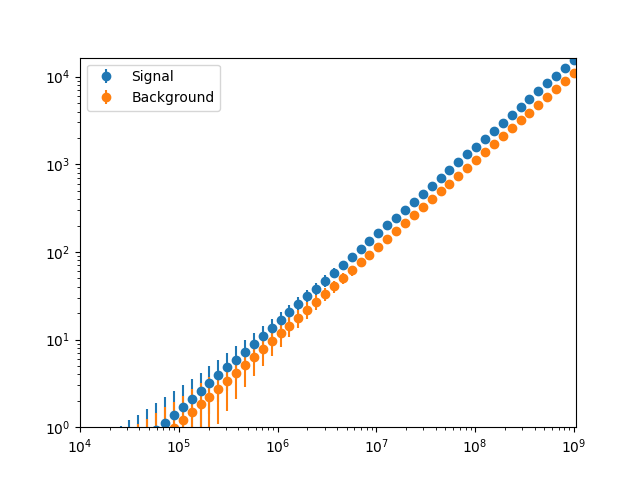

In [197]:
events = np.logspace(0, 9, 101)
bg = bsc_eff * events
sig = (desc_eff + bsc_eff) * events
fig, ax = plt.subplots()
ax.errorbar(events, sig, yerr=np.sqrt(sig), fmt="o", label="Signal")
ax.errorbar(events, bg, yerr=np.sqrt(bg), fmt="o", label="Background")
ax.set_ylim(1)
ax.set_xlim(1e4)
ax.loglog()
ax.legend(loc='best')

## Check if response of a doppler shifted gamma ray can be recreated from 'stationary' response matrix

In [226]:
response = om.Response("respLaBrAfrodite90deg.zip")
respMat, respTab = response.interpolate(np.arange(0, 1401, 1, dtype=float), fwhm_abs=0.03*1332./10, return_table=True)

(<matplotlib.collections.QuadMesh at 0x2cceca120>,
 <Axes: xlabel='$\\gamma$-ray energy $E_{\\gamma}$', ylabel='Excitation energy $E_{x}$'>,
 <Figure size 640x480 with 2 Axes>)

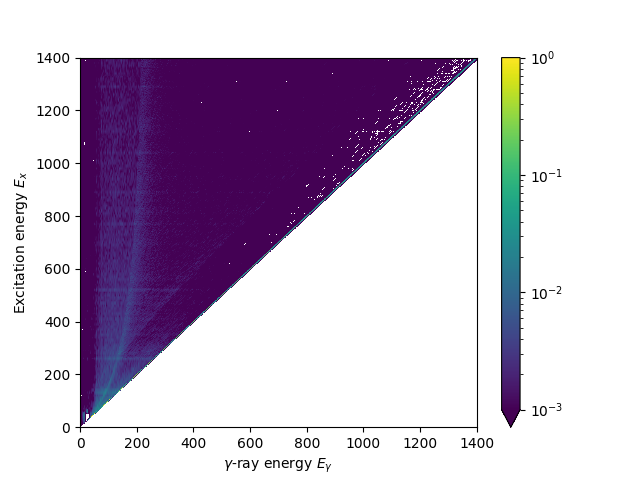

In [232]:
unfolder = om.Unfolder(respMat)
unfolder.R = unfolder._R
unfolder.response_tab = respTab
respMat.plot(vmin=1e-3)

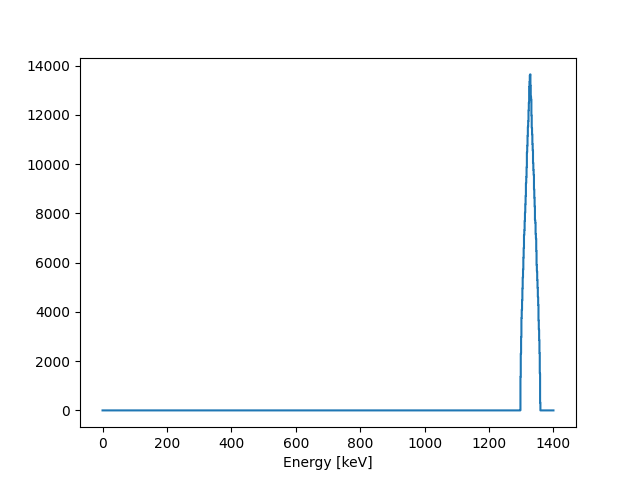

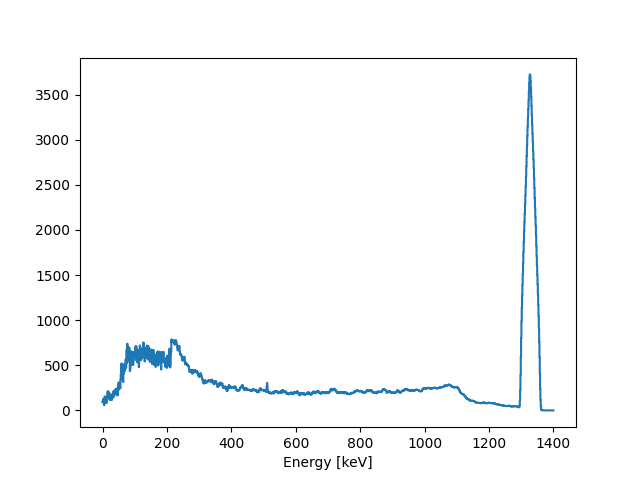

In [264]:
# We are gonna calculate 1e7 angles.
rng = np.random.default_rng()
theta = rng.uniform(0, np.pi, int(1e7))
phi = rng.uniform(0, 2*np.pi, int(1e7))

x = np.cos(phi)*np.sin(theta)
y = np.sin(phi)*np.cos(theta)
z = np.cos(theta)

# First we can exclude all events where x < 0
ϕ = phi[x > 0]
θ = theta[x > 0]
z = z[x > 0]
y = y[x > 0]
x = x[x > 0]


# Scale all vectors to be 16 cm on the x-axis
z = z * 16./x
y = y * 16./x
x = x * 16./x

r = 8.89 / 2. # cm

# Select only those within the disk.
cond = z**2 + y**2 <= r**2
ϕ = ϕ[cond]
θ = θ[cond]
z = z[cond]
y = y[cond]
x = x[cond]

beta = 0.0865
gamma = 1/np.sqrt(1 - beta**2)
energy = 1332.492 / (gamma*(1 - beta*np.cos(θ)))

hist = HistogramData(energy, np.arange(-0.5, 1401, 1, dtype=float))
hist.plot(kind='step')
hist_folded = hist.copy()
folded = unfolder.fold(hist)
folded.plot(kind='step')

In [256]:
rfile = up.open("energy_1332keV.root")
oclEvents4 = rfile['DataTreeSim']['OCLLABR_Energy4'].array(library='np')
oclhist4 = HistogramData(oclEvents4[oclEvents4>0], np.arange(-0.5, 1401, 1))

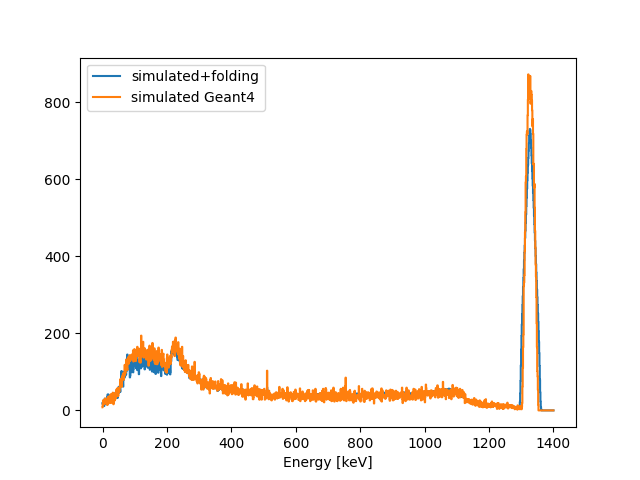

In [276]:
folded_cp = folded.copy()
factor = np.sum(oclhist4.cut(1280, 1380, inplace=False).values)
folded_cp.values /= np.sum(folded_cp.cut(1280, 1380, inplace=False).values)/factor
fig, ax = folded_cp.plot(kind='step', label="simulated+folding")
oclhist4.plot(ax=ax, kind='step', label="simulated Geant4")
ax.legend(loc='best')

6.855654600401044